### Assignment 3
Lily Kendall

You use the Student Academic Success.csv, which was used in the lectures. The categorical predictors are Attendance, Course, Debtor, Displaced, Educational special needs, Gender, International, Marital status, Scholarship holder, and Tuition fees up to date. The continuous predictors are Age at enrollment and Curricular units 1st sem (approved). The label variable is Target, with three categories: Dropout, Enrolled, and Graduate. The reference category is Graduate.

In [ ]:
import pandas as pd
from CHAID import Tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("Student Academic Success.csv", delimiter=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [ ]:
# Columns specified in the assignment instructions
df_keep = df[["Daytime/evening attendance", "Course", "Debtor", "Displaced", "Educational special needs",
              "Gender", "International", "Scholarship holder", "Marital status", "Tuition fees up to date", 
              "Age at enrollment", "Curricular units 1st sem (approved)", "Target"]]
df_keep.head()

,Daytime/evening attendance,Course,Debtor,Displaced,Educational special needs,Gender,International,Scholarship holder,Marital status,Tuition fees up to date,Age at enrollment,Curricular units 1st sem (approved),Target
0,1,2,0,1,0,1,0,0,1,1,20,0,Dropout
1,1,11,0,1,0,1,0,0,1,0,19,6,Graduate
2,1,5,0,1,0,1,0,0,1,0,19,0,Dropout
3,1,15,0,1,0,0,0,0,1,1,20,6,Graduate
4,0,3,0,0,0,0,0,0,2,1,45,5,Graduate


In [7]:
# no missing values, so no need to impute
df_keep.isna().sum()

Daytime/evening attendance             0
Course                                 0
Debtor                                 0
Displaced                              0
Educational special needs              0
Gender                                 0
International                          0
Scholarship holder                     0
Marital status                         0
Tuition fees up to date                0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

***Question 1***

You'll build a simple CHAID tree with a depth of 1 for each categorical predictor that has three or more categories. Afterward, you'll create a table showing the counts of terminal nodes for each of these trees. In this table, each row will represent a node, and you'll include the original predictor categories for each node to make everything clear. Each column will correspond to a label category, helping you easily see the distribution.

In [8]:
# find the number of categories in each categorical variable
categorical_cols = ["Daytime/evening attendance", "Course", "Debtor", "Displaced", "Educational special needs", "Gender", "International", "Marital status", "Scholarship holder", "Tuition fees up to date"]
for col in categorical_cols:
    print(f"{col}: {df_keep[col].nunique()} categories")

Daytime/evening attendance: 2 categories
Course: 17 categories
Debtor: 2 categories
Displaced: 2 categories
Educational special needs: 2 categories
Gender: 2 categories
International: 2 categories
Marital status: 6 categories
Scholarship holder: 2 categories
Tuition fees up to date: 2 categories


In [ ]:
# Distribution of course
df_keep.groupby('Course').describe()

Daytime/evening attendance                                    Debtor  \
                            count mean  std  min  25%  50%  75%  max  count   
Course                                                                        
1                            12.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   12.0   
2                           215.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  215.0   
3                           215.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  215.0   
4                           210.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  210.0   
5                           226.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  226.0   
6                           337.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  337.0   
7                           170.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  170.0   
8                           141.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  141.0   
9                           380.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  380.0   
10                          355.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  355.0   
11                          252.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  252.0   
12                          766.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  766.0   
13                           86.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   86.0   
14                          268.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  268.0   
15                          331.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  331.0   
16                          192.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  192.0   
17                          268.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  268.0   

                  ... Age at enrollment        \
            mean  ...               75%   max   
Course            ...                           
1       0.416667  ...             35.00  37.0   
2       0.134884  ...             21.00  38.0   
3       0.120930  ...             41.00  59.0   
4       0.233333  ...             31.00  60.0   
5       0.084071  ...             21.00  55.0   
6       0.097923  ...             22.00  51.0   
7       0.205882  ...             27.00  49.0   
8       0.177305  ...             25.00  53.0   
9       0.115789  ...             23.00  70.0   
10      0.132394  ...             21.00  53.0   
11      0.091270  ...             22.00  62.0   
12      0.036554  ...             20.00  51.0   
13      0.081395  ...             27.75  54.0   
14      0.141791  ...             22.00  53.0   
15      0.129909  ...             20.00  59.0   
16      0.135417  ...             21.25  45.0   
17      0.097015  ...             38.00  59.0   

       Curricular units 1st sem (approved)                                     \
                                     count      mean       std  min  25%  50%   
Course                                                                          
1                                     12.0  6.750000  7.174766  0.0  1.5  5.5   
2                                    215.0  1.976744  4.642793  0.0  0.0  0.0   
3                                    215.0  5.441860  3.571057  0.0  4.0  6.0   
4                                    210.0  5.471429  4.770488  0.0  2.0  5.0   
5                                    226.0  5.597345  2.653600  0.0  5.0  6.0   
6                                    337.0  4.418398  2.520160  0.0  3.0  5.0   
7                                    170.0  2.441176  2.181026  0.0  0.0  2.5   
8                                    141.0  3.432624  2.508001  0.0  1.0  4.0   
9                                    380.0  3.768421  2.798238  0.0  2.0  4.0   
10                                   355.0  5.188732  2.513441  0.0  5.0  6.0   
11                                   252.0  4.503968  2.392715  0.0  3.0  5.0   
12                                   766.0  6.229765  2.330127  0.0  6.0  7.0   
13                                    86.0  4.662791  2.712110  0.0  2.0  6.0   
14                                   268.0  4.242537  2.099790  0.0  3.0  5.0   
15                                   331.0  4.845921  1.945579  0.0 

In [ ]:
# Distribution of marital status
df_keep.groupby('Marital status').describe()

Daytime/evening attendance                                      \
                                    count      mean       std  min   25%  50%   
Marital status                                                                  
1                                  3919.0  0.931105  0.253308  0.0  1.00  1.0   
2                                   379.0  0.559367  0.497119  0.0  0.00  1.0   
3                                     4.0  0.750000  0.500000  0.0  0.75  1.0   
4                                    91.0  0.593407  0.493919  0.0  0.00  1.0   
5                                    25.0  0.840000  0.374166  0.0  1.00  1.0   
6                                     6.0  0.333333  0.516398  0.0  0.00  0.0   

                           Course             ... Age at enrollment        \
                 75%  max   count       mean  ...               75%   max   
Marital status                                ...                           
1               1.00  1.0  3919.0   9.854810  ...             22.00  61.0   
2               1.00  1.0   379.0  10.292876  ...             43.00  60.0   
3               1.00  1.0     4.0   9.250000  ...             44.00  47.0   
4               1.00  1.0    91.0  10.131868  ...             43.00  70.0   
5               1.00  1.0    25.0  10.640000  ...             34.00  62.0   
6               0.75  1.0     6.0   7.833333  ...             47.75  55.0   

               Curricular units 1st sem (approved)                           \
                                             count      mean       std  min   
Marital status                                                                
1                                           3919.0  4.738199  3.006518  0.0   
2                                            379.0  4.543536  3.748027  0.0   
3                                              4.0  2.000000  2.449490  0.0   
4                                             91.0  4.219780  3.552158  0.0   
5                                             25.0  4.960000  3.724692  0.0   
6                                              6.0  2.500000  2.810694  0.0   

                                      
                25%  50%   75%   max  
Marital status                        
1               3.0  5.0  6.00  26.0  
2               1.0  5.0  6.00  19.0  
3               0.0  1.5  3.50   5.0  
4               1.0  5.0  6.00  18.0  
5               1.0  5.0  7.00  13.0  
6               0.0  2.0  4.75   6.0  

[6 rows x 88 columns]

In [ ]:
# course and marital status have > 3 categories, so we will create CHAID with those
# starting with course
course_tree = Tree.from_pandas_df(df_keep, {'Course': 'nominal'}, 'Target', dep_variable_type='categorical', max_depth=1)

In [15]:
course_tree.print_tree()
course_tree.classification_rules()

([], {'Dropout': 1421.0, 'Enrolled': 794.0, 'Graduate': 2209.0}, (Course, p=1.722877196223912e-108, score=542.7678014922338, groups=[[1, 7], [2, 11, 14, 4, 13], [3, 15], [5, 6], [8, 17], [9, 16], [10, 12]]), dof=12))
|-- ([1, 7], {'Dropout': 100.0, 'Enrolled': 67.0, 'Graduate': 15.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([2, 11, 14, 4, 13], {'Dropout': 392.0, 'Enrolled': 180.0, 'Graduate': 459.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([3, 15], {'Dropout': 172.0, 'Enrolled': 55.0, 'Graduate': 319.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([5, 6], {'Dropout': 141.0, 'Enrolled': 117.0, 'Graduate': 305.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([8, 17], {'Dropout': 214.0, 'Enrolled': 75.0, 'Graduate': 120.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([9, 16], {'Dropout': 219.0, 'Enrolled': 158.0, 'Graduate': 195.0}, <Invalid Chaid Split> - the max depth has been reached)
+-- ([10, 

[{'node': 1, 'rules': [{'variable': 'Course', 'data': [1, 7]}]},
 {'node': 2, 'rules': [{'variable': 'Course', 'data': [2, 11, 14, 4, 13]}]},
 {'node': 3, 'rules': [{'variable': 'Course', 'data': [3, 15]}]},
 {'node': 4, 'rules': [{'variable': 'Course', 'data': [5, 6]}]},
 {'node': 5, 'rules': [{'variable': 'Course', 'data': [8, 17]}]},
 {'node': 6, 'rules': [{'variable': 'Course', 'data': [9, 16]}]},
 {'node': 7, 'rules': [{'variable': 'Course', 'data': [10, 12]}]}]

In [16]:
# marital status tree
marital_tree = Tree.from_pandas_df(df_keep, {'Marital status': 'nominal'}, 'Target', dep_variable_type='categorical', max_depth=1)

marital_tree.print_tree()
marital_tree.classification_rules()

([], {'Dropout': 1421.0, 'Enrolled': 794.0, 'Graduate': 2209.0}, (Marital status, p=2.2388630227530247e-13, score=58.2552761020913, groups=[[1, 3], [2, 5, 4, 6]]), dof=2))
|-- ([1, 3], {'Dropout': 1185.0, 'Enrolled': 722.0, 'Graduate': 2016.0}, <Invalid Chaid Split> - the max depth has been reached)
+-- ([2, 5, 4, 6], {'Dropout': 236.0, 'Enrolled': 72.0, 'Graduate': 193.0}, <Invalid Chaid Split> - the max depth has been reached)



[{'node': 1, 'rules': [{'variable': 'Marital status', 'data': [1, 3]}]},
 {'node': 2, 'rules': [{'variable': 'Marital status', 'data': [2, 5, 4, 6]}]}]

***Question 2***

You'll train a CHAID tree with a depth of 1 for each continuous predictor, considering each unique value as its own category. To make sure each bin has enough observations, you'll set a maximum limit for each predictor. For instance, for Age at enrollment, values over 55 will be capped at 55 (meaning whichever is smaller between 55 and the actual Age at enrollment). Similarly, for Curricular units 1st sem (approved), the cap will be at 15. 

Afterward, you'll create a table showing the counts of terminal nodes for each of these trees. In this table, each row will represent a node, and you'll include the original predictor values for each node to make everything clear. Each column corresponds to a label category, making it easy to see the distribution.


In [20]:
# age at enrollment tree
# first, cap age at 55
df_keep['Age at enrollment'] = df_keep['Age at enrollment'].clip(upper=55)
# create bins for each unique age value/make it categorical
df_keep['Age bins'] = df_keep['Age at enrollment'].astype('category')

age_tree = Tree.from_pandas_df(df_keep, {'Age bins': 'ordinal'}, 'Target', dep_variable_type='categorical', max_depth=1)
age_tree.print_tree()
age_tree.classification_rules()

([], {'Dropout': 1421.0, 'Enrolled': 794.0, 'Graduate': 2209.0}, (Age bins, p=6.511181813973046e-98, score=493.10113043343756, groups=[[17, 18, 19], [20], [21, 22], [23, 24], [25, 26, 27, 28], [29, 30, 31], [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]]), dof=12))
|-- ([17, 18, 19], {'Dropout': 409.0, 'Enrolled': 331.0, 'Graduate': 1212.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([20], {'Dropout': 133.0, 'Enrolled': 140.0, 'Graduate': 326.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([21, 22], {'Dropout': 151.0, 'Enrolled': 107.0, 'Graduate': 238.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([23, 24], {'Dropout': 97.0, 'Enrolled': 54.0, 'Graduate': 88.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([25, 26, 27, 28], {'Dropout': 201.0, 'Enrolled': 67.0, 'Graduate': 93.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([29, 30, 31], {'Dropout': 111.

[{'node': 1, 'rules': [{'variable': 'Age bins', 'data': [17, 18, 19]}]},
 {'node': 2, 'rules': [{'variable': 'Age bins', 'data': [20]}]},
 {'node': 3, 'rules': [{'variable': 'Age bins', 'data': [21, 22]}]},
 {'node': 4, 'rules': [{'variable': 'Age bins', 'data': [23, 24]}]},
 {'node': 5, 'rules': [{'variable': 'Age bins', 'data': [25, 26, 27, 28]}]},
 {'node': 6, 'rules': [{'variable': 'Age bins', 'data': [29, 30, 31]}]},
 {'node': 7,
  'rules': [{'variable': 'Age bins',
    'data': [32,
     33,
     34,
     35,
     36,
     37,
     38,
     39,
     40,
     41,
     42,
     43,
     44,
     45,
     46,
     47,
     48,
     49,
     50,
     51,
     52,
     53,
     54,
     55]}]}]

In [21]:
# curricular units tree
# first, cap curricular units at 15
df_keep['Curricular units 1st sem (approved)'] = df_keep['Curricular units 1st sem (approved)'].clip(upper=15)
# create bins for each unique value/make it categorical
df_keep['Curricular units bins'] = df_keep['Curricular units 1st sem (approved)'].astype('category')

curricular_tree = Tree.from_pandas_df(df_keep, {'Curricular units bins': 'ordinal'}, 'Target', dep_variable_type='categorical', max_depth=1)
curricular_tree.print_tree()
curricular_tree.classification_rules()

([], {'Dropout': 1421.0, 'Enrolled': 794.0, 'Graduate': 2209.0}, (Curricular units bins, p=0.0, score=2041.1332752869678, groups=[[0], [1, 2], [3], [4], [5], [6, 7, 8], [9, 10, 11, 12], [13, 14], [15]]), dof=16))
|-- ([0], {'Dropout': 570.0, 'Enrolled': 71.0, 'Graduate': 77.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([1, 2], {'Dropout': 205.0, 'Enrolled': 75.0, 'Graduate': 7.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([3], {'Dropout': 139.0, 'Enrolled': 93.0, 'Graduate': 37.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([4], {'Dropout': 158.0, 'Enrolled': 145.0, 'Graduate': 130.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([5], {'Dropout': 145.0, 'Enrolled': 193.0, 'Graduate': 385.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([6, 7, 8], {'Dropout': 160.0, 'Enrolled': 194.0, 'Graduate': 1396.0}, <Invalid Chaid Split> - the max depth has been reached)
|-- ([9, 10, 11, 12], {'Dropout': 27.0, 

[{'node': 1, 'rules': [{'variable': 'Curricular units bins', 'data': [0]}]},
 {'node': 2, 'rules': [{'variable': 'Curricular units bins', 'data': [1, 2]}]},
 {'node': 3, 'rules': [{'variable': 'Curricular units bins', 'data': [3]}]},
 {'node': 4, 'rules': [{'variable': 'Curricular units bins', 'data': [4]}]},
 {'node': 5, 'rules': [{'variable': 'Curricular units bins', 'data': [5]}]},
 {'node': 6,
  'rules': [{'variable': 'Curricular units bins', 'data': [6, 7, 8]}]},
 {'node': 7,
  'rules': [{'variable': 'Curricular units bins', 'data': [9, 10, 11, 12]}]},
 {'node': 8,
  'rules': [{'variable': 'Curricular units bins', 'data': [13, 14]}]},
 {'node': 9, 'rules': [{'variable': 'Curricular units bins', 'data': [15]}]}]

***Question 3***

You will train a multinomial logistic regression using the Forward Selection method with an entry threshold of 5%. The predictors are the original categorical predictors with exactly two categories, as well as the CHAID tree leaves. You should create a step summary table that includes step numbers. At each step, include the predictor’s name, the log-likelihood value, the model degrees of freedom, the Chi-square test statistic, the test degrees of freedom, and the significance value of the test.

In [29]:
mnlogit_df = df_keep[["Daytime/evening attendance", "Debtor", "Displaced", "Educational special needs", "Gender", "International", "Scholarship holder", "Tuition fees up to date", "Target"]].copy()

# make course tree into category
groups={0: [1, 7], 1: [2, 11, 14, 4, 13], 2: [3, 15], 3: [5, 6], 4: [8, 17], 5: [9, 16], 6: [10, 12]}
mnlogit_df['Course group'] = df_keep['Course'].map(lambda x: next((k for k, v in groups.items() if x in v), None))
mnlogit_df['Course group'] = mnlogit_df['Course group'].astype('category')

# make marital status tree into category
groups={0: [1, 3], 1: [2, 5, 4, 6]}
mnlogit_df['Marital status group'] = df_keep['Marital status'].map(lambda x: next((k for k, v in groups.items() if x in v), None))
mnlogit_df['Marital status group'] = mnlogit_df['Marital status group'].astype('category')

# make age tree into category
groups={0: [17, 18, 19], 1: [20], 2: [21, 22], 3: [23, 24], 4: [25, 26, 27, 28], 5: [29, 30, 31], 6: [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]}
mnlogit_df['Age group'] = df_keep['Age bins'].map(lambda x: next((k for k,v in groups.items() if x in v), None))
mnlogit_df['Age group'] = mnlogit_df['Age group'].astype('category')

# make curricular units tree into category
groups={0: [0], 1: [1, 2], 2: [3], 3: [4], 4: [5], 5: [6, 7, 8], 6: [9, 10, 11, 12], 7: [13, 14], 8: [15]}
mnlogit_df['Curricular units group'] = df_keep['Curricular units 1st sem (approved)'].map(lambda x: next((k for k, v in groups.items() if x in v), None))
mnlogit_df['Curricular units group'] = mnlogit_df['Curricular units group'].astype('category')

mnlogit_df.head()

,Daytime/evening attendance,Debtor,Displaced,Educational special needs,Gender,International,Scholarship holder,Tuition fees up to date,Target,Course group,Marital status group,Age group,Curricular units group
0,1,0,1,0,1,0,0,1,Dropout,1,0,1,0
1,1,0,1,0,1,0,0,0,Graduate,1,0,0,5
2,1,0,1,0,1,0,0,0,Dropout,3,0,0,0
3,1,0,1,0,0,0,0,1,Graduate,2,0,1,5
4,0,0,0,0,0,0,0,1,Graduate,2,1,6,4


In [ ]:
from LogisticRegression import MultinominalLogisticRegression
import scipy.stats as stats
import numpy as np

# Setup lists of predictors
binary_preds = [
    'Daytime/evening attendance', 'Debtor', 'Displaced', 
    'Educational special needs', 'Gender', 'International', 
    'Scholarship holder', 'Tuition fees up to date'
]
tree_groups = ['Course group', 'Marital status group', 'Age group', 'Curricular units group']

candidates = binary_preds + tree_groups
selected_preds = []
step_summary = []

# Calc baseline log-likelihood 
counts = df['Target'].value_counts()
n_total = len(df)
# Log-likelihood of null model
current_llk = np.sum(counts * np.log(counts / n_total))

# Calculate Baseline Degrees of Freedom
# J is number of categories in Target. Intercept-only DF = (J - 1)
n_categories = len(counts)
current_df = n_categories - 1

print(f"Baseline LLK: {current_llk}")
print(f"Baseline DF: {current_df}")

# Forward selection loop
while len(candidates) > 0:
    best_p_value = 1.0
    best_predictor = None
    best_metrics = {}

    for predictor in candidates:
        # Try adding the predictor to current selected set
        trial_preds = selected_preds + [predictor]
        
        # Fit the trial model
        trial_fit, trial_llk, trial_df, *_ = MultinominalLogisticRegression(
            trainData=mnlogit_df, catPred=trial_preds, intPred=[], nominalLabel='Target', 
            modelSpec=trial_preds, qIntercept=True
        )

        # Calculate test statistics
        chi_sq = 2 * (trial_llk - current_llk)
        test_df = trial_df - current_df
        p_value = stats.chi2.sf(chi_sq, test_df)

        if p_value < best_p_value:
            best_p_value = p_value
            best_predictor = predictor
            best_metrics = {
                'LLK': trial_llk,
                'ModelDF': trial_df,
                'ChiSq': chi_sq,
                'TestDF': test_df,
                'Sig': p_value
            }

            # Print step summary for this predictor
            print(f"Trying to add: {predictor}")
            print(f"  LLK: {trial_llk}")
            print(f"  Model DF: {trial_df}")
            print(f"  Chi-square: {chi_sq}")
            print(f"  Test DF: {test_df}")
            print(f"  p-value: {p_value}")

    # Check the 5% Entry Threshold
    if best_p_value < 0.05:
        selected_preds.append(best_predictor)
        candidates.remove(best_predictor)
        current_llk = best_metrics['LLK']
        current_df = best_metrics['ModelDF']
        
        step_summary.append({
            'Step': len(selected_preds),
            'Predictor': best_predictor,
            'Log-Likelihood': current_llk,
            'Model DF': current_df,
            'Chi-square': best_metrics['ChiSq'],
            'Test DF': best_metrics['TestDF'],
            'Significance': best_metrics['Sig']
        })
    else:
        # No more predictors meet the 5% threshold
        break

summary_df = pd.DataFrame(step_summary)

Baseline LLK: -4511.832788515159
Baseline DF: 2
Optimization terminated successfully.
         Current function value: 1.016736
         Iterations 6
Trying to add: Daytime/evening attendance
  LLK: -4498.0412071815035
  Model DF: 4
  Chi-square: 27.583162667311626
  Test DF: 2
  p-value: 1.0242178256004132e-06
Optimization terminated successfully.
         Current function value: 0.990915
         Iterations 5
Trying to add: Debtor
  LLK: -4383.808225148411
  Model DF: 4
  Chi-square: 256.04912673349645
  Test DF: 2
  p-value: 2.509796918530354e-56
Optimization terminated successfully.
         Current function value: 1.013327
         Iterations 5
Optimization terminated successfully.
         Current function value: 1.019783
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.993439
         Iterations 5
Optimization terminated successfully.
         Current function value: 1.019715
         Iterations 5
Optimization terminated successfully

In [57]:
display(summary_df)

,Step,Predictor,Log-Likelihood,Model DF,Chi-square,Test DF,Significance
0,1,Curricular units group,-3431.956909,18,2159.751759,16,0.000000e+00
1,2,Tuition fees up to date,-3198.486928,20,466.939963,2,4.029725e-102
2,3,Age group,-3107.181567,32,182.610722,12,1.241823e-32
3,4,Scholarship holder,-3054.904669,34,104.553794,2,1.978937e-23
4,5,Course group,-3009.826178,46,90.156983,12,4.603661e-14
5,6,Debtor,-2994.123663,48,31.405030,2,1.515250e-07
6,7,Daytime/evening attendance,-2980.909844,50,26.427637,2,1.825204e-06
7,8,Gender,-2974.163569,52,13.492551,2,1.175249e-03
8,9,International,-2970.935556,54,6.456026,2,3.963617e-02


***Question 4***

You will present the confusion matrix and the row accuracy for the Question 3 model. How does this model compare to the one discussed in the Week 6 lecture?

In [65]:
# fit final model with selected predictors
model_fit, model_llk, model_df, model_param, alias_param, nonalias_param, labelCategories = MultinominalLogisticRegression(
    trainData=mnlogit_df, catPred=selected_preds, intPred=[], nominalLabel='Target', 
    modelSpec=selected_preds, qIntercept=True
)

# Get the predicted probabilities from final model_fit
predicted_probs = model_fit.predict() 

# Find the index of the highest probability for each observation
predicted_indices = predicted_probs.argmax(axis=1)

# Map the indices back to the actual category names
predicted_labels = [labelCategories[i] for i in predicted_indices]

# Get the actual labels
actual_labels = mnlogit_df['Target']

Optimization terminated successfully.
         Current function value: 0.671550
         Iterations 8


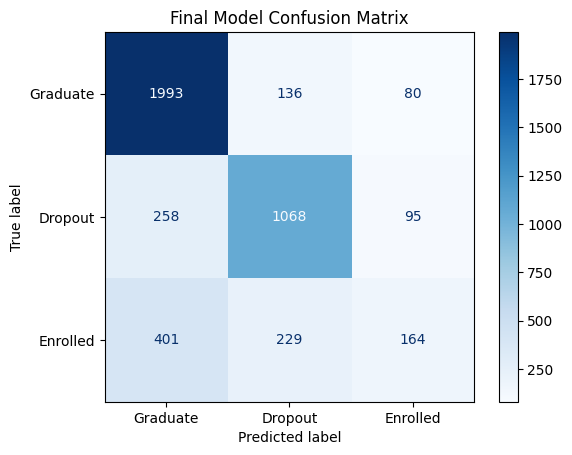

Confusion Matrix with Row Accuracy:
Predicted  Dropout  Enrolled  Graduate  Row Accuracy (%)
Actual                                                  
Dropout       1068        95       258             75.16
Enrolled       229       164       401             20.65
Graduate       136        80      1993             90.22

Overall Model Accuracy: 72.90%


In [ ]:
# Create confusion matrix
conf_matrix_df = pd.crosstab(actual_labels, predicted_labels, 
                             rownames=['Actual'], colnames=['Predicted'])

# Heatmap
cm = confusion_matrix(actual_labels, predicted_labels, labels=labelCategories)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelCategories)

disp.plot(cmap=plt.cm.Blues)
plt.title('Final Model Confusion Matrix')
plt.show()

# Calculate Overall Accuracy
# correct predictions / total predictions
overall_accuracy = np.diag(conf_matrix_df).sum() / conf_matrix_df.values.sum()

# Calculate Row Accuracy
# correct predictions / total row count
row_accuracy = np.diag(conf_matrix_df) / conf_matrix_df.sum(axis=1)

# Add row accuracy
conf_matrix_with_metrics = conf_matrix_df.copy()
conf_matrix_with_metrics['Row Accuracy (%)'] = (row_accuracy * 100).round(2)

print("Confusion Matrix with Row Accuracy:")
print(conf_matrix_with_metrics)
print(f"\nOverall Model Accuracy: {overall_accuracy:.2%}")

***Question 5:***

Building on your model from Question 3, could you find out which predictor value combinations would lead the model to predict the highest probability for each label category?

In [ ]:

# Get predicted probabilities for the entire dataset
all_probs = pd.DataFrame(model_fit.predict(), columns=labelCategories)

# Join probabilities with the predictors used in the final model
final_predictors = selected_preds 
analysis_df = pd.concat([mnlogit_df[final_predictors].reset_index(drop=True), all_probs], axis=1)

# Find the combination with the highest probability for each category
top_profiles_list = []

for category in labelCategories:
    # Find the row with the max probability for the category
    idx_max = analysis_df[category].idxmax()
    
    # Extract the full row
    top_row = analysis_df.loc[idx_max].copy()
    
    # Add a column to identify which category this row represents
    top_row['Target Category'] = category
    top_profiles_list.append(top_row)

# Create summary table
top_profiles_table = pd.DataFrame(top_profiles_list)

cols = ['Target Category'] + [cat for cat in labelCategories] + final_predictors
top_profiles_table = top_profiles_table[cols]

print("Predictor Combinations for Highest Predicted Probabilities:")
display(top_profiles_table)

Predictor Combinations for Highest Predicted Probabilities:


,Target Category,Graduate,Dropout,Enrolled,Curricular units group,Tuition fees up to date,Age group,Scholarship holder,Course group,Debtor,Daytime/evening attendance,Gender,International
1550,Graduate,0.992395,0.004708,0.002897,8.0,1.0,6.0,1.0,2.0,0.0,0.0,0.0,0.0
842,Dropout,0.000344,0.996630,0.003026,0.0,0.0,5.0,0.0,4.0,1.0,1.0,1.0,0.0
2515,Enrolled,0.098361,0.141025,0.760614,3.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
